Cleaned Data Summary:
    neighborhood  rodent_calls  Shape_Area  rats_per_sqft
7      North End         225.0    0.000056   4.008919e+06
4    Bay Village          35.0    0.000012   2.982415e+06
9      South End         438.0    0.000208   2.100926e+06
10      Back Bay         249.0    0.000177   1.410191e+06
14   Beacon Hill         124.0    0.000089   1.400863e+06
24       Allston         328.0    0.000442   7.427540e+05
2   Mission Hill          96.0    0.000155   6.189583e+05
23  South Boston         346.0    0.000637   5.435531e+05
6      Chinatown          17.0    0.000034   5.037145e+05
17      Brighton         384.0    0.000814   4.718664e+05

Total neighborhoods with rodent calls: 25
Total rodent calls: 5008


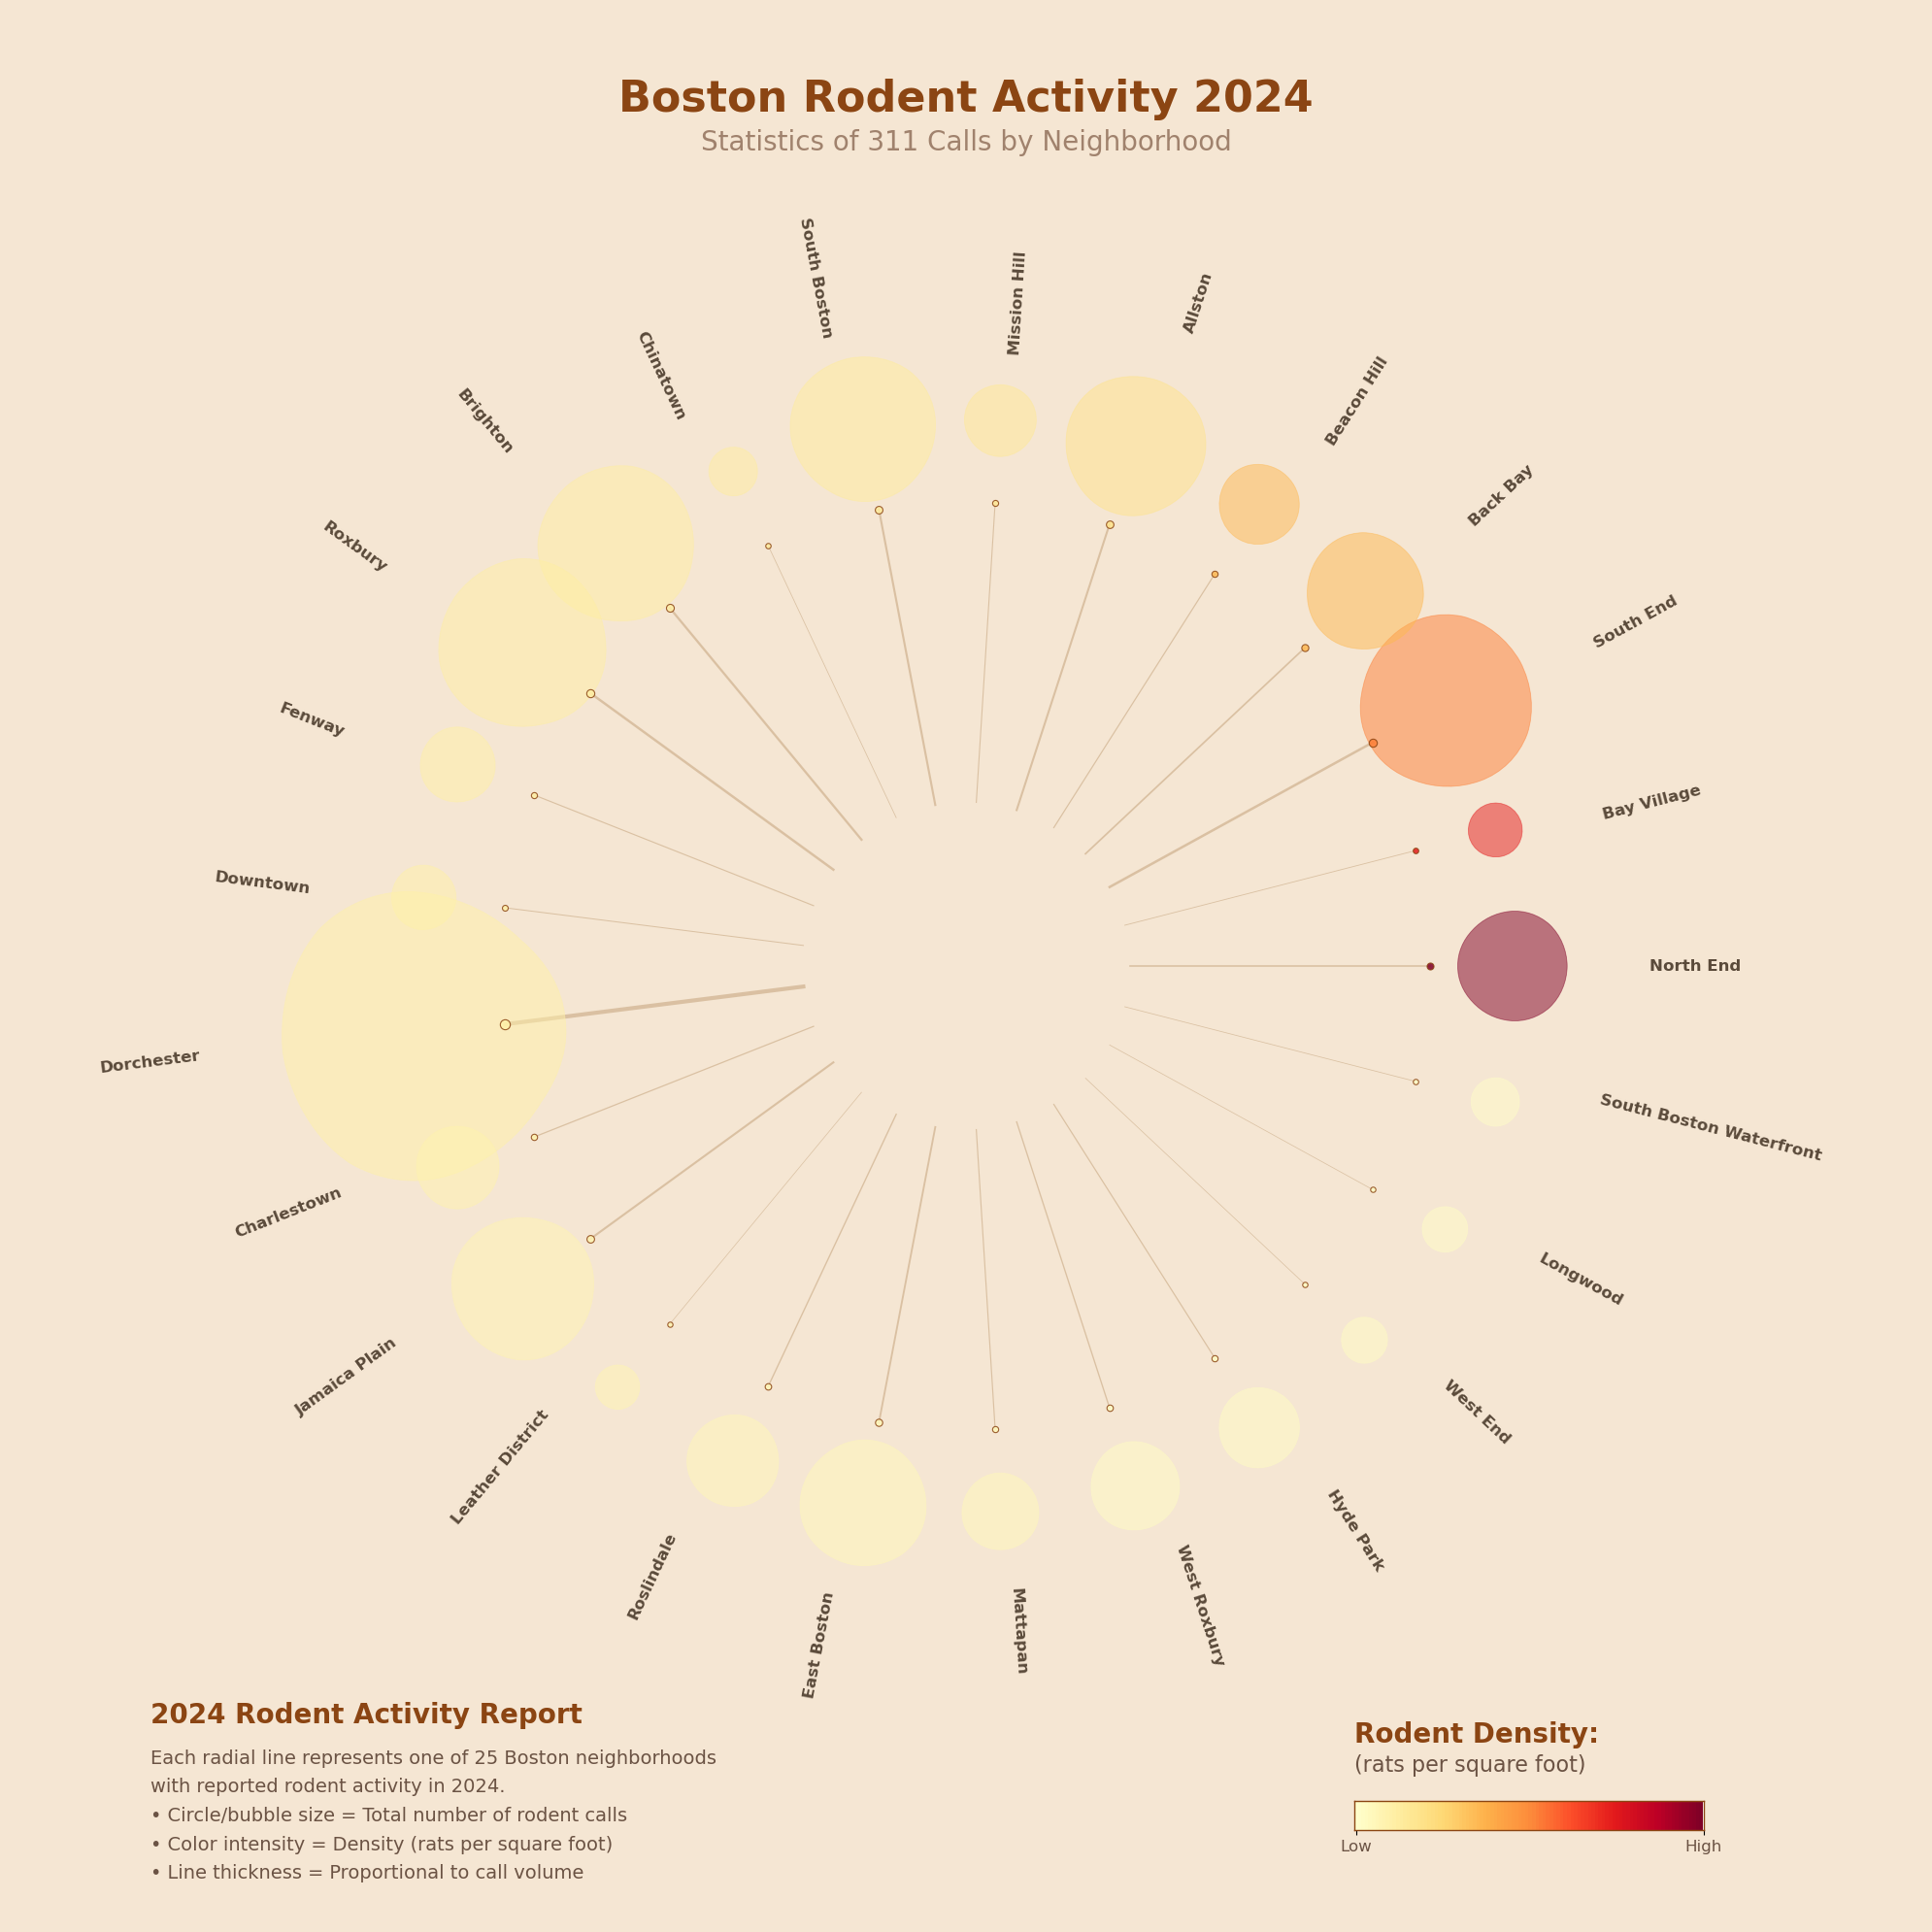

In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import warnings
warnings.filterwarnings('ignore')

# Load the datasets
boston_311 = pd.read_csv('data/Boston_311_2024.csv')
boston_neighborhoods = gpd.read_file('data/Boston_Neighborhood_Boundaries.shp')

# Filter for rodent activity
rats_boston = boston_311[boston_311['type'] == 'Rodent Activity'].copy()

# Remove rows with missing coordinates
rats_boston = rats_boston.dropna(subset=['longitude', 'latitude'])

# Ensure neighborhood GeoDataFrame has the right CRS
if boston_neighborhoods.crs is None:
    boston_neighborhoods = boston_neighborhoods.set_crs('EPSG:4326')
elif boston_neighborhoods.crs != 'EPSG:4326':
    boston_neighborhoods = boston_neighborhoods.to_crs('EPSG:4326')

# Convert rodent calls to GeoDataFrame
rats_boston_gdf = gpd.GeoDataFrame(
    rats_boston,
    geometry=gpd.points_from_xy(rats_boston['longitude'], rats_boston['latitude']),
    crs='EPSG:4326'
)

# Spatial join to assign each rodent call to a neighborhood
rats_boston_gdf_by_neighborhood = gpd.sjoin(rats_boston_gdf, boston_neighborhoods, how='left', predicate='within')

# Determine the neighborhood column name from the shapefile
neighborhood_col = None
for col in boston_neighborhoods.columns:
    if col.lower() in ['neighborhood', 'name', 'blockgr2020', 'nhood', 'nbhd']:
        neighborhood_col = col
        break

if neighborhood_col is None:
    print("Available columns in shapefile:", boston_neighborhoods.columns.tolist())
    raise ValueError("Could not find neighborhood name column in shapefile")

# Determine shape area column name
area_col = None
for col in boston_neighborhoods.columns:
    if 'area' in col.lower() or col == 'Shape_Area':
        area_col = col
        break

if area_col is None:
    # Calculate area from geometry
    boston_neighborhoods['calculated_area'] = boston_neighborhoods.geometry.area
    area_col = 'calculated_area'

# Group by neighborhood and count rodent calls
rat_counts = rats_boston_gdf_by_neighborhood.groupby(neighborhood_col).size().reset_index(name='rodent_calls')

# Merge with neighborhood data
boston_neighborhoods = boston_neighborhoods.merge(rat_counts, on=neighborhood_col, how='left')
boston_neighborhoods['rodent_calls'] = boston_neighborhoods['rodent_calls'].fillna(0)

# Calculate rats per square foot
boston_neighborhoods['rats_per_sqft'] = boston_neighborhoods['rodent_calls'] / boston_neighborhoods[area_col]

# Create cleaned dataframe
cleaned_df = boston_neighborhoods[[neighborhood_col, 'rodent_calls', area_col, 'rats_per_sqft']].copy()
cleaned_df.columns = ['neighborhood', 'rodent_calls', 'Shape_Area', 'rats_per_sqft']
cleaned_df = cleaned_df[cleaned_df['rodent_calls'] > 0].sort_values('rats_per_sqft', ascending=False)

# Save cleaned dataframe
cleaned_df.to_csv('data/boston_rodent_analysis_cleaned.csv', index=False)

print("Cleaned Data Summary:")
print(cleaned_df.head(10))
print(f"\nTotal neighborhoods with rodent calls: {len(cleaned_df)}")
print(f"Total rodent calls: {cleaned_df['rodent_calls'].sum():.0f}")

# Create Radial Visualization (Nobel Prize style)
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='polar')

# Set background color
fig.patch.set_facecolor('#F5E6D3')
ax.set_facecolor('#F5E6D3')

# Prepare data
neighborhoods_with_calls = cleaned_df.copy().reset_index(drop=True)
n_neighborhoods = len(neighborhoods_with_calls)

# Calculate angles for each neighborhood (evenly distributed around circle)
angles = np.linspace(0, 2 * np.pi, n_neighborhoods, endpoint=False)

# Normalize values for visualization
max_calls = neighborhoods_with_calls['rodent_calls'].max()
max_density = neighborhoods_with_calls['rats_per_sqft'].max()

# Color based on density
colors_density = plt.cm.YlOrRd(neighborhoods_with_calls['rats_per_sqft'] / max_density)

# Draw radial lines and dots from center
center_radius = 0.25
line_start = 0.3
line_end = 0.85  # Fixed length for cleaner look

for i, (idx, row) in enumerate(neighborhoods_with_calls.iterrows()):
    angle = angles[i]
    
    # Draw line with varying thickness based on call count
    line_thickness = 0.5 + (row['rodent_calls'] / max_calls) * 2.5
    ax.plot([angle, angle], [line_start, line_end], 
            color='#C8A882', linewidth=line_thickness, alpha=0.6, zorder=1)
    
    # Draw small dot at end of line
    dot_size = 15 + (row['rodent_calls'] / max_calls) * 40
    ax.scatter(angle, line_end, s=dot_size, 
              color=colors_density[i], 
              edgecolor='#8B4513', linewidth=0.8,
              alpha=0.85, zorder=3)

# Draw outer ring with bubbles (larger and more transparent)
outer_ring_radius = 1.0
bubble_angles = angles.copy()

for i, (idx, row) in enumerate(neighborhoods_with_calls.iterrows()):
    angle = bubble_angles[i]
    
    # Larger bubble size based on total calls
    bubble_radius = 0.04 + (row['rodent_calls'] / max_calls) * 0.22
    
    # Create bubble with lower opacity
    bubble = Circle((angle, outer_ring_radius), bubble_radius,
                   color=colors_density[i], alpha=0.5,
                   edgecolor='#8B4513', linewidth=0.6,
                   transform=ax.transData, zorder=2)
    ax.add_patch(bubble)
    
    # Add neighborhood name (rotated to follow the circle, larger font)
    # Calculate text angle in degrees
    text_angle_deg = np.degrees(angle)
    
    # Adjust text orientation so it's readable (not upside down)
    if 90 < text_angle_deg < 270:
        text_angle_deg = text_angle_deg - 180
        ha = 'right'
        text_radius = outer_ring_radius + bubble_radius + 0.15
    else:
        ha = 'left'
        text_radius = outer_ring_radius + bubble_radius + 0.15
    
    # Add neighborhood name
    neighborhood_name = row['neighborhood']
    
    ax.text(angle, text_radius, neighborhood_name,
            rotation=text_angle_deg,
            ha=ha, va='center',
            fontsize=12, color='#5A4A3A', fontweight='bold',
            zorder=4)


ax.text(0, -0.10, "Total Rodent\nCalls 2024",
        ha='center', va='center',
        fontsize=12, color='#6B5344', linespacing=1.5,
        transform=ax.transData, zorder=6)

# Remove default polar plot elements
ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)
ax.grid(False)
ax.set_ylim(0, 1.75)

# Add title
fig.text(0.5, 0.94, 'Boston Rodent Activity 2024', 
         ha='center', fontsize=32, fontweight='bold', color='#8B4513')
fig.text(0.5, 0.92, 'Statistics of 311 Calls by Neighborhood', 
         ha='center', fontsize=20, color='#A0826D')

# Add legend (moved to bottom corners, outside the map area)
legend_y = 0.06
fig.text(0.08, legend_y + 0.05, '2024 Rodent Activity Report', 
         fontsize=20, fontweight='bold', color='#8B4513')

description = (f"Each radial line represents one of {n_neighborhoods} Boston neighborhoods\n"
               f"with reported rodent activity in 2024.\n"
               f"• Circle/bubble size = Total number of rodent calls\n"
               f"• Color intensity = Density (rats per square foot)\n"
               f"• Line thickness = Proportional to call volume")
fig.text(0.08, legend_y - 0.03, description,
         fontsize=14, color='#6B5344', linespacing=1.7)

# Add color legend (moved to bottom right)
legend_x = 0.70
fig.text(legend_x, legend_y + 0.04, 'Rodent Density:', 
         fontsize=20, fontweight='bold', color='#8B4513')
fig.text(legend_x, legend_y + 0.025, '(rats per square foot)', 
         fontsize=16, color='#6B5344')

# Create gradient bar
gradient = np.linspace(0, 1, 100).reshape(1, -1)
ax_gradient = fig.add_axes([legend_x, legend_y - 0.005, 0.18, 0.015])
ax_gradient.imshow(gradient, aspect='auto', cmap='YlOrRd')
ax_gradient.set_xticks([0, 100])
ax_gradient.set_xticklabels(['Low', 'High'], fontsize=12, color='#6B5344')
ax_gradient.set_yticks([])
for spine in ax_gradient.spines.values():
    spine.set_edgecolor('#8B4513')
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig('boston_rats_nopics.png', dpi=300, bbox_inches='tight', facecolor='#F5E6D3')
plt.show()